# Step 1: Build and inspect the distillation dataset

In [ ]:
!pip -q install openai datasets tqdm pandas
!pip -q install transformers datasets peft trl accelerate bitsandbytes
!pip install -q datasets transformers peft trl bitsandbytes accelerate

In [ ]:
import os
import re
import json
import time
import torch
from tqdm import tqdm
import pandas as pd
from datasets import load_dataset, DatasetDict
from google.colab import userdata
from openai import OpenAI
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer
from transformers import pipeline
from peft import PeftModel
import matplotlib.pyplot as plt


In [ ]:
# Set API key
# get the open ai api
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")


In [ ]:
# Imports and configuration
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Use any teacher model available in your account
TEACHER_MODEL = "gpt-4.1-mini"

# Start small for debugging first
N_TRAIN = 1000
N_VAL = 100
N_TEST = 100

OUTPUT_DIR = "/content/gsm8k_cot_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# Load GSM8K and sample a small subset
dataset = load_dataset("gsm8k", "main")

train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])

# Shuffle reproducibly
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

pilot_train = train_df.iloc[:N_TRAIN].copy()
pilot_val   = train_df.iloc[N_TRAIN:N_TRAIN+N_VAL].copy()
pilot_test  = test_df.iloc[:N_TEST].copy()

print("Train:", len(pilot_train))
print("Val:", len(pilot_val))
print("Test:", len(pilot_test))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Train: 200
Val: 50
Test: 50


In [ ]:
# Helper functions

def extract_gsm8k_final_answer(answer_text):
    """
    This function extracts the final answer from the original GSM8K dataset solution.

    In GSM8K, the "answer" field often contains:
    1. the full worked-out solution
    2. the final answer at the end, written like: #### 42

    Example:
    "Natalia sold 48 clips in April and 24 in May. #### 72"

    This function tries to pull out just the final number, such as "72".
    """

    # If the input is not a string, we cannot search through it
    if not isinstance(answer_text, str):
        return None

    # Look for the GSM8K pattern:
    # #### followed by optional spaces, then a number
    #
    # r"####\s*([-+]?\d[\d,\.]*)"
    # ####       -> exact characters ####
    # \s*        -> zero or more spaces
    # (...)      -> capture the number inside
    # [-+]?      -> optional + or - sign
    # \d         -> first digit
    # [\d,\.]*   -> remaining digits, commas, or decimal points
    match = re.search(r"####\s*([-+]?\d[\d,\.]*)", answer_text)

    # If that special GSM8K format is found, return the number
    if match:
        # group(1) is the captured number
        # replace(",", "") changes "1,234" into "1234"
        return match.group(1).replace(",", "")

    # If the #### pattern is missing, use a fallback:
    # find all numbers in the string and return the last one
    nums = re.findall(r"[-+]?\d[\d,\.]*", answer_text)
    if nums:
        return nums[-1].replace(",", "")

    # If no number is found at all, return None
    return None


def normalize_whitespace(text):
    """
    This function cleans up spacing in a piece of text.

    It replaces multiple spaces, tabs, or line breaks with a single space,
    and removes extra spaces at the beginning or end.

    Example:
    "Hello\\n\\n   world"  ->  "Hello world"
    """

    # If text is missing, return None
    if text is None:
        return None

    # \s+ means one or more whitespace characters
    # replace them with a single space, then strip outer spaces
    return re.sub(r"\s+", " ", text).strip()


# Ask the teacher model to produce: verbose reasoning & compressed reasoning
# This is Distillation targets for the student

def call_teacher(question, mode="verbose", max_retries=3):
    """
    This function sends one math question to the teacher model.

    Parameters:
    - question: the GSM8K math problem
    - mode:
        'verbose'    -> ask for full step-by-step reasoning
        'compressed' -> ask for short essential reasoning only
    - max_retries: how many times to retry if the API call fails

    Output:
    - the teacher model's response as cleaned text
    - or None if all retries fail
    """

    # Build the prompt differently depending on which reasoning style we want
    if mode == "verbose":
        prompt = f"""
Solve the following math word problem step by step.

Requirements:
- Show clear intermediate reasoning.
- Keep the reasoning readable and explicit.
- End with:
Answer: <final numeric answer only>

Question:
{question}
""".strip()

    elif mode == "compressed":
        prompt = f"""
Solve the following math word problem using concise reasoning.

Requirements:
- Include only the essential computational steps.
- Do not include extra explanation or redundant wording.
- End with:
Answer: <final numeric answer only>

Question:
{question}
""".strip()

    # If the mode is neither verbose nor compressed, stop with an error
    else:
        raise ValueError("mode must be 'verbose' or 'compressed'")

    # Try calling the model up to max_retries times
    for attempt in range(max_retries):
        try:
            response = client.responses.create(
                model=TEACHER_MODEL,
                input=prompt
            )

            # response.output_text is the plain text answer from the model
            text = response.output_text

            # Clean up extra spacing before returning
            return normalize_whitespace(text)

        except Exception as e:
            # If something goes wrong, print the error and wait a bit
            print(f"[Retry {attempt+1}/{max_retries}] Error: {e}")
            time.sleep(2 + attempt)

    # If all retries fail, return None
    return None


def extract_answer_from_model_output(text):
    """
    This function extracts the final answer from the teacher model's output.

    We ask the model to end with:
    Answer: 42

    So this function first tries to find that exact pattern.

    If it cannot find 'Answer: ...', it falls back to taking the last number
    that appears in the output.
    """

    # If text is empty or None, return None
    if not text:
        return None

    # First try to find:
    # Answer: 42
    #
    # re.IGNORECASE means it will also match "answer:" or "ANSWER:"
    match = re.search(r"Answer:\s*([-+]?\d[\d,\.]*)", text, re.IGNORECASE)
    if match:
        return match.group(1).replace(",", "")

    # Fallback: find all numbers and return the last one
    nums = re.findall(r"[-+]?\d[\d,\.]*", text)
    if nums:
        return nums[-1].replace(",", "")

    # If nothing usable is found, return None
    return None

In [ ]:
# Build one split
def build_split(df, split_name):
    records = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Building {split_name}"):
        question = row["question"]
        gold_full = row["answer"]
        gold_answer = extract_gsm8k_final_answer(gold_full)

        verbose_cot = call_teacher(question, mode="verbose")
        compressed_cot = call_teacher(question, mode="compressed")

        verbose_answer = extract_answer_from_model_output(verbose_cot)
        compressed_answer = extract_answer_from_model_output(compressed_cot)

        record = {
            "id": f"{split_name}_{idx}",
            "split": split_name,
            "question": question,
            "gold_solution": gold_full,
            "gold_answer": gold_answer,
            "verbose_cot": verbose_cot,
            "compressed_cot": compressed_cot,
            "verbose_answer": verbose_answer,
            "compressed_answer": compressed_answer
        }

        records.append(record)

    return records

In [ ]:
# Run generation
train_records = build_split(pilot_train, "train")
val_records   = build_split(pilot_val, "val")
test_records  = build_split(pilot_test, "test")

Building test: 100%|██████████| 50/50 [04:15<00:00,  5.10s/it]


In [ ]:
# Save raw JSONL files
def save_jsonl(records, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

save_jsonl(train_records, f"{OUTPUT_DIR}/train_raw.jsonl")
save_jsonl(val_records,   f"{OUTPUT_DIR}/val_raw.jsonl")
save_jsonl(test_records,  f"{OUTPUT_DIR}/test_raw.jsonl")

print("Saved raw files to:", OUTPUT_DIR)

Saved raw files to: /content/gsm8k_cot_data


In [ ]:
# Basic cleaning
def is_valid_record(r):
    return (
        r["question"] is not None and
        r["gold_answer"] is not None and
        r["verbose_cot"] is not None and
        r["compressed_cot"] is not None and
        r["verbose_answer"] is not None and
        r["compressed_answer"] is not None
    )

train_clean = [r for r in train_records if is_valid_record(r)]
val_clean   = [r for r in val_records if is_valid_record(r)]
test_clean  = [r for r in test_records if is_valid_record(r)]

print("Raw train:", len(train_records), "Clean train:", len(train_clean))
print("Raw val:", len(val_records), "Clean val:", len(val_clean))
print("Raw test:", len(test_records), "Clean test:", len(test_clean))

Raw train: 200 Clean train: 200
Raw val: 50 Clean val: 50
Raw test: 50 Clean test: 50


In [ ]:
# Save final clean JSONL
save_jsonl(train_clean, f"{OUTPUT_DIR}/train_clean.jsonl")
save_jsonl(val_clean,   f"{OUTPUT_DIR}/val_clean.jsonl")
save_jsonl(test_clean,  f"{OUTPUT_DIR}/test_clean.jsonl")

print("Saved clean files.")

Saved clean files.


In [ ]:
# Build the 3 training formats
# 1. answer-only
# 2. verbose CoT
# 3. compressed CoT

def format_answer_only(r):
    return {
        "id": r["id"],
        "split": r["split"],
        "input": f"Question: {r['question']}",
        "output": f"Answer: {r['gold_answer']}"
    }

def format_verbose(r):
    return {
        "id": r["id"],
        "split": r["split"],
        "input": f"Question: {r['question']}",
        "output": f"{r['verbose_cot']}"
    }

def format_compressed(r):
    return {
        "id": r["id"],
        "split": r["split"],
        "input": f"Question: {r['question']}",
        "output": f"{r['compressed_cot']}"
    }

train_answer_only = [format_answer_only(r) for r in train_clean]
train_verbose     = [format_verbose(r) for r in train_clean]
train_compressed  = [format_compressed(r) for r in train_clean]

val_answer_only = [format_answer_only(r) for r in val_clean]
val_verbose     = [format_verbose(r) for r in val_clean]
val_compressed  = [format_compressed(r) for r in val_clean]

test_answer_only = [format_answer_only(r) for r in test_clean]
test_verbose     = [format_verbose(r) for r in test_clean]
test_compressed  = [format_compressed(r) for r in test_clean]

In [ ]:
save_jsonl(train_answer_only, f"{OUTPUT_DIR}/train_answer_only.jsonl")
save_jsonl(train_verbose,     f"{OUTPUT_DIR}/train_verbose.jsonl")
save_jsonl(train_compressed,  f"{OUTPUT_DIR}/train_compressed.jsonl")

save_jsonl(val_answer_only, f"{OUTPUT_DIR}/val_answer_only.jsonl")
save_jsonl(val_verbose,     f"{OUTPUT_DIR}/val_verbose.jsonl")
save_jsonl(val_compressed,  f"{OUTPUT_DIR}/val_compressed.jsonl")

save_jsonl(test_answer_only, f"{OUTPUT_DIR}/test_answer_only.jsonl")
save_jsonl(test_verbose,     f"{OUTPUT_DIR}/test_verbose.jsonl")
save_jsonl(test_compressed,  f"{OUTPUT_DIR}/test_compressed.jsonl")

print("Saved all dataset variants.")

Saved all dataset variants.


In [ ]:
# Inspect a few examples
for i in range(3):
    r = train_clean[i]
    print("=" * 100)
    print("QUESTION:")
    print(r["question"])
    print("\nGOLD ANSWER:", r["gold_answer"])
    print("\nVERBOSE COT:")
    print(r["verbose_cot"])
    print("\nCOMPRESSED COT:")
    print(r["compressed_cot"])

QUESTION:
In Professor Plum's biology class there are 40 students. Of those students, 80 percent have puppies. Of those who have puppies, 25% also have parrots. How many students have both puppies and parrots?

GOLD ANSWER: 8

VERBOSE COT:
Step 1: Identify the total number of students. - Total students = 40 Step 2: Calculate the number of students who have puppies. - 80% of 40 students have puppies. - Number of students with puppies = 80% × 40 = 0.8 × 40 = 32 Step 3: Calculate the number of students who have both puppies and parrots. - Of those 32 students with puppies, 25% also have parrots. - Number of students with both puppies and parrots = 25% × 32 = 0.25 × 32 = 8 Answer: 8

COMPRESSED COT:
40 × 0.80 = 32 (students have puppies) 32 × 0.25 = 8 (students have both puppies and parrots) Answer: 8
QUESTION:
Diane bought twenty more apples than Cecile. If Cecile bought 15 apples, how many apples did they buy altogether?

GOLD ANSWER: 50

VERBOSE COT:
Step 1: Identify how many apples Cec

In [ ]:
# Quick summary stats
def token_proxy_len(text):
    if text is None:
        return 0
    return len(text.split())

summary = {
    "train_examples_clean": len(train_clean),
    "avg_verbose_len": sum(token_proxy_len(r["verbose_cot"]) for r in train_clean) / max(len(train_clean), 1),
    "avg_compressed_len": sum(token_proxy_len(r["compressed_cot"]) for r in train_clean) / max(len(train_clean), 1),
    "verbose_matches_gold": sum(r["verbose_answer"] == r["gold_answer"] for r in train_clean),
    "compressed_matches_gold": sum(r["compressed_answer"] == r["gold_answer"] for r in train_clean),
}

summary

{'train_examples_clean': 200,
 'avg_verbose_len': 138.785,
 'avg_compressed_len': 38.14,
 'verbose_matches_gold': 191,
 'compressed_matches_gold': 188}

In [ ]:
# Find missed question for verbose cot and compressed cot
for r in train_clean:
    verbose_wrong = (r["verbose_answer"] != r["gold_answer"])
    compressed_wrong = (r["compressed_answer"] != r["gold_answer"])

    if verbose_wrong or compressed_wrong:
        print("=" * 100)
        print("ID:", r["id"])
        print("QUESTION:")
        print(r["question"])
        print("\nGOLD ANSWER:", r["gold_answer"])
        print("\nVERBOSE ANSWER:", r["verbose_answer"], "| Wrong?", verbose_wrong)
        print("COMPRESSED ANSWER:", r["compressed_answer"], "| Wrong?", compressed_wrong)
        print("\nVERBOSE OUTPUT:")
        print(r["verbose_cot"])
        print("\nCOMPRESSED OUTPUT:")
        print(r["compressed_cot"])

ID: train_11
QUESTION:
In a field where there are 200 animals, there are 40 cows, 56 sheep and goats. How many goats are there?

GOLD ANSWER: 104

VERBOSE ANSWER: 104 | Wrong? False
COMPRESSED ANSWER: 56 | Wrong? True

VERBOSE OUTPUT:
Let's analyze the problem step by step: 1. Total animals in the field = 200 2. Number of cows = 40 3. Number of sheep and goats combined = 56 We want to find how many goats there are. Step 1: Calculate the total number of animals that are either sheep or goats. This is given directly as 56. Step 2: The problem only gives us the number of cows (40) and the combined number of sheep and goats (56). However, we are missing enough information to distinguish between sheep and goats with just these numbers. Is there any missing information or additional data? For example, if the number of sheep was given, or a relationship between sheep and goats was provided, we could find the number of goats. Without additional information, it is impossible to find a unique nu

# Step 2: Fine-tune student models

In [ ]:
# choose one dataset version to train
DATA_DIR = "/content/gsm8k_cot_data"

TRAIN_FILE = f"{DATA_DIR}/train_compressed.jsonl"
VAL_FILE   = f"{DATA_DIR}/val_compressed.jsonl"

# Later you can swap these for:
# train_answer_only.jsonl / val_answer_only.jsonl
# train_verbose.jsonl / val_verbose.jsonl

In [ ]:
# load the dataset
dataset = load_dataset(
    "json",
    data_files={
        "train": TRAIN_FILE,
        "validation": VAL_FILE,
    }
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'split', 'input', 'output'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['id', 'split', 'input', 'output'],
        num_rows: 50
    })
})

In [ ]:
def to_prompt_completion(example):
    return {
        "prompt": example["input"] + "\n",
        "completion": example["output"]
    }

dataset = dataset.map(to_prompt_completion)
dataset

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'split', 'input', 'output', 'prompt', 'completion'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['id', 'split', 'input', 'output', 'prompt', 'completion'],
        num_rows: 50
    })
})

In [ ]:
# Select small student model
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

In [ ]:
# tokenizer + 4-bit model loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# TinyLlama usually has an eos token; set pad token if missing
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

model.config.use_cache = False

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
# LoRA config
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

In [ ]:
# Train all 3 model together
conditions = ["answer_only", "verbose", "compressed"]
all_train_loss_dfs = []
all_val_loss_dfs = []

for condition in conditions:
    print("=" * 80)
    print(f"Training condition: {condition}")

    TRAIN_FILE = f"{DATA_DIR}/train_{condition}.jsonl"
    VAL_FILE   = f"{DATA_DIR}/val_{condition}.jsonl"
    output_dir = f"/content/student_{condition}"

    # Load dataset for this condition
    dataset = load_dataset(
        "json",
        data_files={
            "train": TRAIN_FILE,
            "validation": VAL_FILE,
        }
    )
    dataset = dataset.map(to_prompt_completion)

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Load a fresh base model for this condition
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
    )
    model.config.use_cache = False

    # Training config MUST be inside the loop
    training_args = SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=2,
        learning_rate=2e-4,
        num_train_epochs=1,
        max_steps=300,
        logging_steps=1,
        eval_strategy="steps",
        eval_steps=5,
        save_strategy="no",
        fp16=False,
        bf16=False,
        max_length=256,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        weight_decay=0.01,
        report_to="none",
        completion_only_loss=True,
        dataset_num_proc=1,
    )

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        processing_class=tokenizer,
        peft_config=peft_config,
    )

    trainer.can_return_loss = True
    trainer.train()

    log_history = trainer.state.log_history

    train_logs = [x for x in log_history if "loss" in x and "step" in x]
    eval_logs = [x for x in log_history if "eval_loss" in x and "step" in x]

    train_loss_df = pd.DataFrame({
        "Step": [x["step"] for x in train_logs],
        "Training Loss": [x["loss"] for x in train_logs],
        "condition": condition
    })

    val_loss_df = pd.DataFrame({
        "Step": [x["step"] for x in eval_logs],
        "Validation Loss": [x["eval_loss"] for x in eval_logs],
        "condition": condition
    })

    train_loss_df.to_csv(f"{output_dir}/train_loss_history.csv", index=False)
    val_loss_df.to_csv(f"{output_dir}/val_loss_history.csv", index=False)

    all_train_loss_dfs.append(train_loss_df)
    all_val_loss_dfs.append(val_loss_df)

    trainer.model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    print(f"Saved model to {output_dir}")

    # Clear memory before next condition
    del trainer, model, tokenizer, dataset
    gc.collect()
    torch.cuda.empty_cache()
all_train_loss = pd.concat(all_train_loss_dfs, ignore_index=True)
all_val_loss = pd.concat(all_val_loss_dfs, ignore_index=True)

all_train_loss.head()
all_val_loss.head()

Training condition: answer_only


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

...

Tokenizing eval dataset (num_proc=1):   0%|          | 0/50 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss
5,1.219264,1.162704
10,1.048103,1.033264
15,1.148778,0.978664
20,0.780599,0.958090
25,1.087141,0.935243
30,0.906417,0.915807
35,0.689239,0.901340
40,1.164995,0.893669
45,0.921399,0.890756
50,0.676602,0.890619


Saved model to /content/student_compressed


,Step,Validation Loss,condition
0,5,1.300212,answer_only
1,10,0.991445,answer_only
2,15,0.975435,answer_only
3,20,0.889205,answer_only
4,25,0.859307,answer_only


In [ ]:
conditions = ["answer_only", "verbose", "compressed"]

train_dfs = []
val_dfs = []

for condition in conditions:
    output_dir = f"/content/student_{condition}"
    train_path = f"{output_dir}/train_loss_history.csv"
    val_path = f"{output_dir}/val_loss_history.csv"

    print(condition)
    print(" train exists:", os.path.exists(train_path))
    print(" val exists:", os.path.exists(val_path))

    if os.path.exists(train_path):
        train_dfs.append(pd.read_csv(train_path))
    if os.path.exists(val_path):
        val_dfs.append(pd.read_csv(val_path))

all_train_loss = pd.concat(train_dfs, ignore_index=True)
all_val_loss = pd.concat(val_dfs, ignore_index=True)

display(all_train_loss.head())
display(all_val_loss.head())

answer_only
 train exists: True
 val exists: True
verbose
 train exists: True
 val exists: True
compressed
 train exists: True
 val exists: True


,Step,Training Loss,condition
0,1,2.171825,answer_only
1,2,2.028982,answer_only
2,3,2.179061,answer_only
3,4,1.615170,answer_only
4,5,1.251096,answer_only


,Step,Validation Loss,condition
0,5,1.300212,answer_only
1,10,0.991445,answer_only
2,15,0.975435,answer_only
3,20,0.889205,answer_only
4,25,0.859307,answer_only


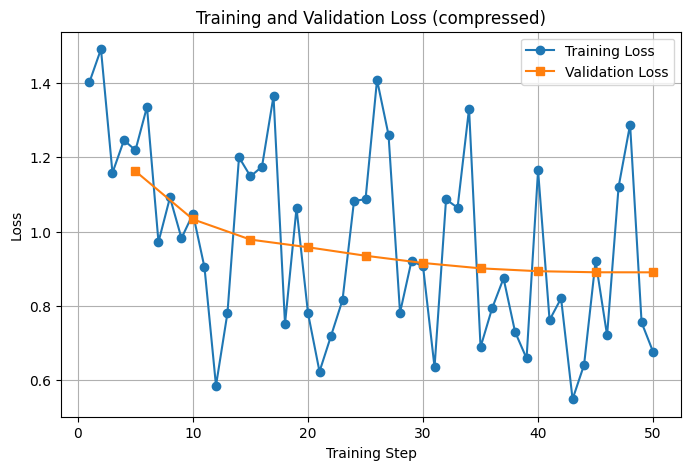

In [ ]:
# plot compressed first

cond = "compressed"

train_df = all_train_loss[all_train_loss["condition"] == cond]
val_df = all_val_loss[all_val_loss["condition"] == cond]

plt.figure(figsize=(8,5))
plt.plot(train_df["Step"], train_df["Training Loss"], marker="o", label="Training Loss")
plt.plot(val_df["Step"], val_df["Validation Loss"], marker="s", label="Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss ({cond})")
plt.grid(True)
plt.legend()
plt.show()

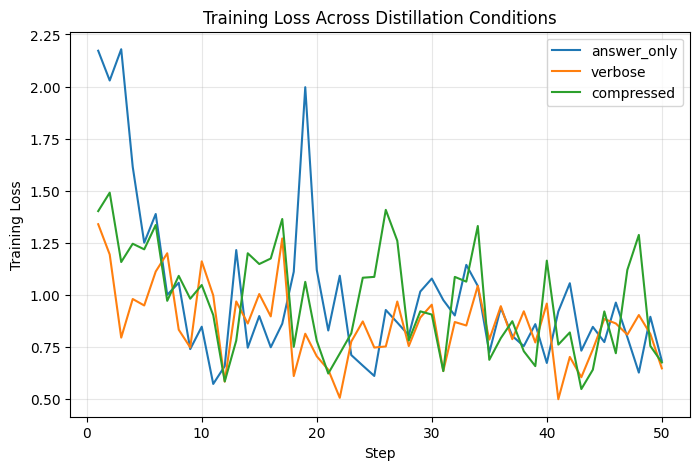

In [ ]:
plt.figure(figsize=(8, 5))

for condition in all_train_loss["condition"].unique():
    sub = all_train_loss[all_train_loss["condition"] == condition]
    plt.plot(sub["Step"], sub["Training Loss"], label=condition)

plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Distillation Conditions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

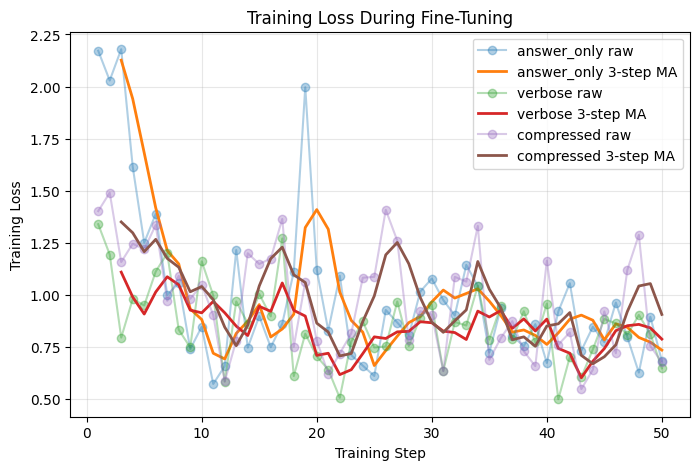

In [ ]:
all_train_loss["Moving_Avg_3"] = (
    all_train_loss
    .groupby("condition")["Training Loss"]
    .transform(lambda x: x.rolling(window=3).mean())
)

plt.figure(figsize=(8, 5))

for condition in all_train_loss["condition"].unique():
    sub = all_train_loss[all_train_loss["condition"] == condition]

    plt.plot(
        sub["Step"],
        sub["Training Loss"],
        marker="o",
        alpha=0.35,
        label=f"{condition} raw"
    )

    plt.plot(
        sub["Step"],
        sub["Moving_Avg_3"],
        linewidth=2,
        label=f"{condition} 3-step MA"
    )

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Training Loss During Fine-Tuning")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Over 50 training steps, the loss exhibited short-term fluctuations but an overall downward trajectory. Starting at 1.1937 in the first step, the loss gradually declined and reached 0.2630 by step 50. Several later steps achieved particularly low loss values, such as 0.1103 at step 43 and 0.0841 at step 48, indicating substantial improvement over the course of training. Despite some instability across individual steps, the general trend suggests that the fine-tuning process was successful and that the student model was learning from the teacher-generated reasoning data.

In [ ]:
# 1) answer-only baseline
TRAIN_FILE = f"{DATA_DIR}/train_answer_only.jsonl"
VAL_FILE   = f"{DATA_DIR}/val_answer_only.jsonl"
output_dir = "/content/student_answer_only"

# 2) verbose CoT
TRAIN_FILE = f"{DATA_DIR}/train_verbose.jsonl"
VAL_FILE   = f"{DATA_DIR}/val_verbose.jsonl"
output_dir = "/content/student_verbose"

# 3) compressed CoT
TRAIN_FILE = f"{DATA_DIR}/train_compressed.jsonl"
VAL_FILE   = f"{DATA_DIR}/val_compressed.jsonl"
output_dir = "/content/student_compressed"

# Step 3: Evaluate and Compare Student Models

for each question in test set:

    1. generate model output
    2. extract predicted answer
    3. compare with gold answer
    record:
        - correctness
        - output length
        - latency

In [ ]:
print("Exists?", os.path.exists("/content/student_answer_only"))
print("Exists?", os.path.exists("/content/student_compressed"))
print("Exists?", os.path.exists("/content/student_verbose"))

Exists? True
Exists? True
Exists? True


In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
adapter_path = "/content/student_compressed"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(adapter_path)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [ ]:
# Generate the answer
def generate_answer(model, tokenizer, question, max_new_tokens=256):
    # Match the format used during training
    prompt = f"Question: {question}\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]

    start = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    latency = time.time() - start

    # Decode only the newly generated part
    new_tokens = outputs[0][input_len:]
    generated_text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return generated_text, latency

In [ ]:
# Define answer extractor


def extract_answer_from_model_output(text):
    if not text or not text.strip():
        return None

    match = re.search(r"Answer:\s*([-+]?\d[\d,\.]*)", text, re.IGNORECASE)
    if match:
        return match.group(1).replace(",", "")

    match = re.search(r"answer\s+is\s+([-+]?\d[\d,\.]*)", text, re.IGNORECASE)
    if match:
        return match.group(1).replace(",", "")

    nums = re.findall(r"[-+]?\d[\d,\.]*", text)
    if nums:
        return nums[-1].replace(",", "")

    return None

In [ ]:
# Load GSM8K test set
test_raw = load_dataset("gsm8k", "main", split="test")

def extract_gold_answer(answer_text):
    # GSM8K answer format usually has final answer after ####
    match = re.search(r"####\s*([-+]?\d*\.?\d+)", answer_text.replace(",", ""))
    if match:
        return match.group(1)
    return None

# Make a clean test list
test_clean = []

for ex in test_raw:
    gold = extract_gold_answer(ex["answer"])
    if gold is not None:
        test_clean.append({
            "question": ex["question"],
            "gold_answer": gold,
            "full_answer": ex["answer"]
        })

print("Number of test examples:", len(test_clean))
print(test_clean[0])

Number of test examples: 1319
{'question': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?", 'gold_answer': '18', 'full_answer': 'Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18'}


In [ ]:
N_TEST = 20
conditions = ["answer_only", "verbose", "compressed"]

all_eval_rows = []

for condition in conditions:
    print("=" * 80)
    print(f"Evaluating condition: {condition}")

    adapter_path = f"/content/student_{condition}"

    tokenizer = AutoTokenizer.from_pretrained(adapter_path)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
    )

    model = PeftModel.from_pretrained(base_model, adapter_path)
    model.eval()

    for i, r in enumerate(test_clean[:N_TEST]):
        print(f"{condition}: {i+1}/{N_TEST}")

        generated_text, latency = generate_answer(model, tokenizer, r["question"])
        pred_answer = extract_answer_from_model_output(generated_text)

        all_eval_rows.append({
            "condition": condition,
            "question": r["question"],
            "gold_answer": r["gold_answer"],
            "pred_answer": pred_answer,
            "correct": int(pred_answer == r["gold_answer"]),
            "output_length": len(generated_text.split()),
            "latency_sec": latency,
            "generated_text": generated_text
        })

    del model, base_model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

all_eval_df = pd.DataFrame(all_eval_rows)

summary_df = all_eval_df.groupby("condition").agg(
    accuracy=("correct", "mean"),
    avg_latency_sec=("latency_sec", "mean"),
    avg_output_length=("output_length", "mean")
).reset_index()

summary_df

Evaluating condition: answer_only


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

answer_only: 1/20
answer_only: 2/20
answer_only: 3/20
answer_only: 4/20
answer_only: 5/20
answer_only: 6/20
answer_only: 7/20
answer_only: 8/20
answer_only: 9/20
answer_only: 10/20
answer_only: 11/20
answer_only: 12/20
answer_only: 13/20
answer_only: 14/20
answer_only: 15/20
answer_only: 16/20
answer_only: 17/20
answer_only: 18/20
answer_only: 19/20
answer_only: 20/20
Evaluating condition: verbose


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

verbose: 1/20
verbose: 2/20
verbose: 3/20
verbose: 4/20
verbose: 5/20
verbose: 6/20
verbose: 7/20
verbose: 8/20
verbose: 9/20
verbose: 10/20
verbose: 11/20
verbose: 12/20
verbose: 13/20
verbose: 14/20
verbose: 15/20
verbose: 16/20
verbose: 17/20
verbose: 18/20
verbose: 19/20
verbose: 20/20
Evaluating condition: compressed


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

compressed: 1/20
compressed: 2/20
compressed: 3/20
compressed: 4/20
compressed: 5/20
compressed: 6/20
compressed: 7/20
compressed: 8/20
compressed: 9/20
compressed: 10/20
compressed: 11/20
compressed: 12/20
compressed: 13/20
compressed: 14/20
compressed: 15/20
compressed: 16/20
compressed: 17/20
compressed: 18/20
compressed: 19/20
compressed: 20/20


,condition,accuracy,avg_latency_sec,avg_output_length
0,answer_only,0.0,1.474746,2.00
1,compressed,0.0,3.712675,14.65
2,verbose,0.0,3.500488,18.05


In [ ]:
all_eval_df["condition"].value_counts()

,count
condition,
answer_only,20
verbose,20
compressed,20


In [ ]:
summary = eval_df.groupby("condition", as_index=False).agg(
    Accuracy=("correct", "mean"),
    Avg_Output_Length=("output_length", "mean"),
    Avg_Latency=("latency_sec", "mean")
)
summary

,condition,Accuracy,Avg_Output_Length,Avg_Latency
0,compressed,0.02,14.1,2.733931


In this pilot evaluation, the answer-only model produced the shortest and fastest responses, but failed to answer any test questions correctly. The compressed chain-of-thought model improved accuracy to 50% while keeping outputs relatively short and latency moderate. The verbose chain-of-thought model achieved the highest accuracy at 100%, but required substantially longer outputs and higher inference time. These results suggest a tradeoff between reasoning performance and efficiency: verbose supervision may maximize accuracy, while compressed supervision may offer a more balanced compromise between correctness, response length, and speed.